# Poisoning Data Pipeline: Cleaning and Deduplication

**Goal:** This notebook processes raw Excel data from the Poison Control Hotline (Giftlinjen) for two patient age cohorts (`<70` and `>70`).
The objective is to clean the dataset, identify and merge duplicate records belonging to the same medical case, filter out non-relevant inquiries (e.g., theoretical questions with no risk), and finally visualize the most common substances involved in actual poisoning cases.

**Key Steps:**

1. **Load & Decrypt:** Read the password-protected Excel file.
2. **Standardize & Filter:** Map synonymous medicine names to a single canonical name and drop rows completely unrelated to medicine.
3. **Cleanse Data:** Fix data entry quirks (like changing `ZZMED` to `MED`).
4. **Deduplicate:** Group multiple calls about the same case into single chronological records.
5. **Prune:** Remove theoretical questions and isolated non-medical substance entries (e.g., just "RUS" or "KEMI").
6. **Visualize:** Generate pie charts of the Top 10 medicines per cohort.
    

In [45]:
# ---------------------------------------------------------------------------
# Imports - All external libraries required for this notebook
# ---------------------------------------------------------------------------
import io
import json
from collections import Counter
from getpass import getpass
import itertools

import numpy as np
import pandas as pd
import msoffcrypto
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Configure Pandas display options so we can see full dataframes when inspecting
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)


In [46]:
# Controls extra output
debugOutput = False

### Configuration and Constants

To make the notebook maintainable, we store all our file paths, rules, and dynamically generated column names in one place. If the data structure changes in the future, you only need to update this block.


In [47]:
# ---------------------------------------------------------------------------
# Global Configuration & Column Generation
# ---------------------------------------------------------------------------
# File paths
FILE_PATH = r"C:\Users\danam\OneDrive\Desktop\Bachelorprojekt\Tidligere excel bearbejdninger\Alle Giftlinjen 2018-2022 (anonym) Aldersfordelt - Kopi.xlsx"
MEDICINE_NAMES_FILE = 'unique_medicine_names.txt'
SYNONYMS_FILE = 'equivalent_names.json'

# Sheet names to load
SHEET_NAMES = ["Alder<70", "Alder>70"] 

# Dynamically generate the 1-15 numbered columns using list comprehensions
generisk_cols = [f'[generisk navn(gift{i})]'.lower() for i in range(1, 16)]
navn_cols     = [f'[navn(gift{i})]'.lower()         for i in range(1, 16)]
subst_cols    = [f'[substans type(gift{i})]'.lower() for i in range(1, 16)]

# Group our columns logically
NAME_COLS = generisk_cols + navn_cols
EXTRA_COLS = ['[råd(tekst)]', '[anamnese(tekst)]']
ALL_MED_COLS = NAME_COLS + EXTRA_COLS

# Deduplication configuration
MAX_GAP_DAYS = 4
DATE_COL = '[today(oprettelse)]'
KEY_COLS = [
    '[søg postnummer(postalcode)]',
    '[mand(patient data)]',
    '[alder (år)(patient data)]'
]
SEMI_COLS = [
    '[styrke(gift1)]', '[antal(gift1)]', '[dosis(gift1)]', '[søg hospital(hospital)]'
]
CAUSE_COLS = [
    '[ulykke/uheld(årsag)]', '[leg(årsag)]', '[suicidal/affekt(årsag)]',
    '[misbrug(årsag)]', '[forveksling(årsag)]', '[omhældning(årsag)]',
    '[fejldosering(årsag)]', '[levnedsmiddel(årsag)]'
]


### Step 1: Loading and Decrypting the Data

We read the encrypted Excel file into memory. We only keep the specific columns necessary for our analysis to save memory, and we force all column headers to lowercase immediately to prevent case-sensitivity bugs later.


In [48]:
# Function to load and prepare the data
def load_and_decrypt_excel(file_path, sheets):
    password = getpass("Enter Excel password: ")
    decrypted = io.BytesIO()
    
    with open(file_path, "rb") as f:
        office = msoffcrypto.OfficeFile(f)
        office.load_key(password=password)
        office.decrypt(decrypted)
        
    decrypted.seek(0)
    
    # We must explicitly include the 15 substance columns so the pruner can see them
    keep = ALL_MED_COLS + subst_cols + KEY_COLS + SEMI_COLS + CAUSE_COLS + [
        DATE_COL, '[indtag tid(gift1)]', '[ingen risiko(risiko)]', 
        '[akut forgiftning(forespørgselsart)]', '[søg by(postalcode)]'
    ]
    
    dfs = pd.read_excel(decrypted, sheet_name=sheets)
    
    for sheet in sheets:
        dfs[sheet].columns = [str(c).lower().strip() for c in dfs[sheet].columns]
        
        valid_keep = [c for c in keep if c in dfs[sheet].columns]
        dfs[sheet] = dfs[sheet][valid_keep]
        
        if DATE_COL in dfs[sheet].columns:
            dfs[sheet][DATE_COL] = pd.to_datetime(dfs[sheet][DATE_COL], errors='coerce')
            
    return dfs[sheets[0]], dfs[sheets[1]]

# Execute the load
young, old = load_and_decrypt_excel(FILE_PATH, SHEET_NAMES)

In [49]:
# Display a quick check of the loaded data
print(f"Loaded 'young' cohort with {len(young)} rows.")
print(f"Loaded 'old' cohort with {len(old)} rows.")

if debugOutput:
    display(young.head(2))

Loaded 'young' cohort with 154529 rows.
Loaded 'old' cohort with 8620 rows.


### Step 2: Standardizing Synonyms and Initial Filtering

Medicines are often typed differently (e.g., "Panodil" vs "Paracetamol"). We load our predefined synonym mapping. We then scan our rows. If a row does *not* contain any recognized medicine in its 30 structured columns, we assume it is not a medicine-related case and drop it entirely.

In [50]:
# ---------------------------------------------------------------------------
# Helper Functions for Text Processing & Filtering
# ---------------------------------------------------------------------------
def split_words(text: str):
    """Tokenize a string by replacing punctuation with spaces and splitting."""
    return text.replace(',', ' ').replace(';', ' ').replace('/', ' ').lower().split()

def build_word_frequencies(dfs, columns) -> Counter:
    """Counts how often every word appears across all specified columns."""
    freq = Counter()
    for df in dfs:
        for col in columns:
            if col in df.columns:
                for entry in df[col].dropna().astype(str).values:
                    freq.update(split_words(entry))
    return freq

def create_canonical_map(synonym_groups, raw_frequencies):
    """Assigns the most frequently used spelling as the 'canonical' name for a group."""
    mapping = {}
    for group in synonym_groups:
        group = [g.lower() for g in group]
        best_freq = max(raw_frequencies.get(g, 0) for g in group)
        candidates = [g for g in group if raw_frequencies.get(g, 0) == best_freq]
        canonical = max(candidates, key=len) # Tie-breaker: longest string
        for g in group:
            mapping[g] = canonical
    return mapping


# ---------------------------  FIXED SECTION  -------------------------------
def filter_rows_without_medicine_inplace(df, known_medicines):
    """
    Drops rows in-place if they don't contain a known medicine in NAME_COLS.
    Now also detects multi-word medicines that appear as a substring
    inside a longer free-text entry (same logic as the old script).
    """
    # Pre-compute the multi-word medicines once for speed
    multi_word_medicines = {m for m in known_medicines if ' ' in m}

    def row_has_medicine(row) -> bool:
        for col in NAME_COLS:
            val = row.get(col)
            if pd.isnull(val):
                continue

            entry = str(val).strip().lower()

            # 1. exact cell match
            if entry in known_medicines:
                return True

            # 2. any single token matches
            words = split_words(entry)
            if any(w in known_medicines for w in words):
                return True

            # 3. any multi-word medicine occurs as a substring
            if any(mw in entry for mw in multi_word_medicines):
                return True

        return False

    mask = df.apply(row_has_medicine, axis=1)
    df.drop(index=df[~mask].index, inplace=True)
    df.reset_index(drop=True, inplace=True)

# ---------------------------------------------------------------------------
# Execution
# ---------------------------------------------------------------------------
# Load reference data
with open(MEDICINE_NAMES_FILE, encoding='utf-8') as f:
    medicines = set(line.strip().lower() for line in f if line.strip())

with open(SYNONYMS_FILE, encoding='utf-8') as f:
    synonym_groups = json.load(f)

# Build our standard dictionary
raw_freq = build_word_frequencies([young, old], ALL_MED_COLS)
synonym_to_canonical = create_canonical_map(synonym_groups, raw_freq)

# Mutate DataFrames in-place to remove non-medicine rows
filter_rows_without_medicine_inplace(young, medicines)
filter_rows_without_medicine_inplace(old, medicines)


In [51]:
# Display remaining row counts
print(f"Remaining rows after medicine filter - Young: {len(young)}")
print(f"Remaining rows after medicine filter - Old: {len(old)}")

Remaining rows after medicine filter - Young: 54036
Remaining rows after medicine filter - Old: 5611


### Step 3: Cleaning Substance Types (`ZZMED` -> `MED`)

Due to data entry habits, some rows denote medicine substances as `ZZMED`. We want to standardize all of these to `MED` across the 15 substance columns.

In [52]:
def convert_zzmed_inplace(df):
    """Replaces all instances of 'ZZMED' with 'MED' in the substance columns in-place."""
    cols = [c for c in subst_cols if c in df.columns]
    total_changes = 0
    
    for c in cols:
        mask = df[c].astype(str).str.upper().eq('ZZMED')
        total_changes += mask.sum()
        df.loc[mask, c] = 'MED'
        
    return int(total_changes)

young_changes = convert_zzmed_inplace(young)
old_changes = convert_zzmed_inplace(old)

In [53]:
print(f"ZZMED to MED conversions applied - Young: {young_changes}")
print(f"ZZMED to MED conversions applied - Old: {old_changes}")

ZZMED to MED conversions applied - Young: 28531
ZZMED to MED conversions applied - Old: 3629


### Step 4: Duplicate Detection (The Clique Algorithm)

Often, a single poisoning case results in multiple calls to the hotline over a few days. We need to cluster these rows into a single "Case".
Two rows are considered part of the same case if:

1. Their demographics (Zip code, Gender, Age) match exactly.
2. The smaller list of poisons in one row is a strict subset of the larger list in the other row.
3. They occur within `MAX_GAP_DAYS` of each other.
4. They do not contradict each other in the semi-hard columns or cause columns.

*Note: The inner helper functions for the clustering algorithm have been extracted for readability.*

In [54]:
# ---------------------------------------------------------------------------
# Deduplication Helper Functions
# ---------------------------------------------------------------------------
def _row_to_poison_set(row_vals):
    out = set()
    for v in row_vals:
        if pd.notna(v) and (txt := str(v).strip()):
            for w in split_words(txt.lower()):
                if w in medicines:
                    out.add(synonym_to_canonical.get(w, w))
    return frozenset(out)

def _clusters_in_segment(seg: pd.DataFrame):
    """Finds mutually compatible rows (cliques) inside a chronological time-segment."""
    n = len(seg)
    if n < 2: return []

    cause_dat = seg[CAUSE_COLS].to_numpy(copy=False)
    cause_nn  = ~pd.isna(cause_dat)
    semi_dat  = seg[SEMI_COLS].to_numpy(copy=False)
    semi_nn   = ~pd.isna(semi_dat)
    p_sets    = seg['__poison_set'].tolist()

    # Prioritize rows with the most data filled in
    order = np.argsort(-cause_nn.sum(axis=1))
    clusters = [] 

    for pos in order:
        placed = False
        for cl in clusters:
            c_idx = np.asarray(cl)
            
            # 1. Asymmetric Cause mismatches
            cand_cause_nn, cand_cause_vals = cause_nn[pos], cause_dat[pos]
            ref_cause_nn, ref_cause_vals = cause_nn[c_idx], cause_dat[c_idx]
            cond1 = cand_cause_nn & (~ref_cause_nn)
            cond2 = cand_cause_nn & ref_cause_nn & (cand_cause_vals != ref_cause_vals)
            if (cond1 | cond2).any(): continue

            # 2. Symmetric Semi-hard mismatches
            cand_semi_nn, cand_semi_vals = semi_nn[pos], semi_dat[pos]
            ref_semi_nn, ref_semi_vals = semi_nn[c_idx], semi_dat[c_idx]
            if (cand_semi_nn & ref_semi_nn & (cand_semi_vals != ref_semi_vals)).any(): continue

            # 3. Poison subset mismatches
            set_c = p_sets[pos]
            u_cluster = frozenset().union(*(p_sets[idx] for idx in c_idx))
            mism_poison = not (set_c <= u_cluster)
            if mism_poison: continue

            cl.append(pos)
            placed = True
            break

        if not placed:
            clusters.append([pos])

    return [seg.iloc[cl].copy() for cl in clusters if len(cl) >= 2]

def find_duplicates(df):
    """Scans the dataframe and returns a dataframe of ONLY the duplicate rows, tagged with IDs."""
    df_temp = df.copy()
    df_temp['__poison_set'] = df_temp[NAME_COLS].apply(_row_to_poison_set, axis=1)

    is_dup = pd.Series(False, index=df_temp.index, dtype=bool)
    dup_case_id = pd.Series(np.nan, index=df_temp.index, dtype='float')
    cid = 0

    # Group by Demographics
    for _, grp in df_temp.groupby(KEY_COLS, sort=False, observed=True):
        grp = grp.sort_values(DATE_COL)
        # Segment by time gaps
        gap = grp[DATE_COL].diff().dt.days.abs().fillna(MAX_GAP_DAYS + 1)
        grp['__seg'] = (gap > MAX_GAP_DAYS).cumsum()

        for _, seg in grp.groupby('__seg', sort=False):
            for cl in _clusters_in_segment(seg):
                idx = cl.index
                is_dup.loc[idx] = True
                dup_case_id.loc[idx] = cid
                cid += 1

    result = df_temp[is_dup].copy()
    if not result.empty:
        result['is_duplicate'] = True
        result['dup_case_id'] = dup_case_id[is_dup].astype('int64')
        result.drop(columns='__poison_set', inplace=True)
    return result

# Execution
young_dups = find_duplicates(young)
old_dups = find_duplicates(old)

In [55]:
print(f"Young cohort duplicate cases detected: {young_dups['dup_case_id'].nunique() if not young_dups.empty else 0}")
print(f"Old cohort duplicate cases detected: {old_dups['dup_case_id'].nunique() if not old_dups.empty else 0}")

Young cohort duplicate cases detected: 5849
Old cohort duplicate cases detected: 479


### Step 5: Merging Duplicates In-Place

Now that we have identified which rows belong to the same case, we merge them.
For strings, we concatenate the texts. For numbers/dates, we keep the first recorded value. Finally, we remove the original individual rows and append the merged, single row representation back into the DataFrame.

In [56]:
def _merge_one_cluster(grp: pd.DataFrame, prototype: pd.DataFrame) -> dict:
    """Collapses a cluster of duplicate rows into a single dictionary representing one case."""
    if DATE_COL in grp.columns:
        grp = grp.sort_values(DATE_COL)

    row = {}
    for col in prototype.columns:
        ser = grp[col].dropna()
        if ser.empty:
            row[col] = np.nan
            continue

        if pd.api.types.is_string_dtype(prototype[col].dtype) or prototype[col].dtype == object:
            vals = [str(v) for v in ser.unique() if str(v).strip() != ""]
            row[col] = " | ".join(vals) if vals else np.nan
        else:
            row[col] = ser.iloc[0]

    row["dup_case_id"] = grp["dup_case_id"].iloc[0]
    row["is_duplicate"] = True
    return row

def merge_duplicates_inplace(df: pd.DataFrame, dup_df: pd.DataFrame):
    """Mutates df in-place by removing old dupes and appending merged single rows."""
    if dup_df.empty: return

    # Build the merged rows
    merged_rows = [
        _merge_one_cluster(grp, df) 
        for _, grp in dup_df.groupby("dup_case_id", sort=False)
    ]
    merged_df = pd.DataFrame(merged_rows)
    
    # In-place drop of the old individual rows
    df.drop(index=dup_df.index, inplace=True)
    
    # Ensure our target dataframe has the tracker columns before concatenating
    if "is_duplicate" not in df.columns:
        df["is_duplicate"] = False
        df["dup_case_id"] = np.nan
        
    # Append the new merged rows. We use pd.concat, but we must update the reference.
    # Note: To fully mimic in-place with concat, we modify the caller's reference.
    return pd.concat([df, merged_df], ignore_index=True)

# Execute
young = merge_duplicates_inplace(young, young_dups)
old = merge_duplicates_inplace(old, old_dups)

In [57]:
print(f"Rows in Young cohort after merge: {len(young)}")
print(f"Rows in Old cohort after merge: {len(old)}")

Rows in Young cohort after merge: 47029
Rows in Old cohort after merge: 5060


### Step 6: Pruning Non-Poisoning Cases

Some records exist where the caller simply asked a theoretical question, or the hotline determined there was "Ingen risiko" (No risk). We drop these records from the data entirely as they don't represent actual poisoning events.
We will wrap these rules into a single data-cleaning pipeline function.

In [58]:
def prune_non_poisoning_inplace(df):
    """Applies multiple dropping rules in-place to remove non-relevant queries."""
    before = len(df)
    
    akut_col = '[akut forgiftning(forespørgselsart)]'
    risiko_col = '[ingen risiko(risiko)]'
    
    # 1. Drop "Teoretisk forespørgsel" where Risk is missing or "Ingen risiko"
    mask_teoretisk = (
        df[akut_col].astype(str).str.lower().eq('teoretisk forespørgsel') &
        (df[risiko_col].isna() | df[risiko_col].astype(str).str.strip().str.lower().eq('ingen risiko'))
    )
    df.drop(index=df[mask_teoretisk].index, inplace=True)
    
    # 2. Drop rows where Query is missing, AND Risk is missing or "Ingen risiko"
    mask_missing_query = (
        df[akut_col].isna() &
        (df[risiko_col].isna() | df[risiko_col].astype(str).str.strip().str.lower().eq('ingen risiko'))
    )
    df.drop(index=df[mask_missing_query].index, inplace=True)
    
    # 3. Drop rows unless Query is missing OR contains "forgiftning"
    keep_mask = (
        df[akut_col].isna() |
        df[akut_col].astype(str).str.lower().str.contains('forgiftning', na=False)
    )
    df.drop(index=df[~keep_mask].index, inplace=True)
    
    df.reset_index(drop=True, inplace=True)
    return before - len(df)

# Execute
pruned_young = prune_non_poisoning_inplace(young)
pruned_old = prune_non_poisoning_inplace(old)

In [59]:
print(f"Non-poisoning rows pruned - Young: {pruned_young}")
print(f"Non-poisoning rows pruned - Old: {pruned_old}")

Non-poisoning rows pruned - Young: 3356
Non-poisoning rows pruned - Old: 401


### Step 7: Removing Isolated Non-Medical Substances

Sometimes a row only lists a generic category like "RUS" (intoxicants), "BIO", "KEMI", or "DIVERSE" across all 15 substance slots, with no actual medicine listed. Because this analysis focuses strictly on medicines, we drop rows where these categories are the *only* recorded substances.

In [60]:
def remove_solitary_substances_inplace(df, target_substances):
    """
    Removes rows where the ONLY substance present is one of the targets.
    Uses boolean indexing to avoid index misalignment warnings.
    """
    # 1. Ensure the DataFrame is index-aligned
    df = df.reset_index(drop=True)
    
    # 2. Build the substance cleaning block
    # We create this subset from the current, aligned df
    subst_clean = df.reindex(columns=subst_cols).fillna('').astype(str).apply(lambda c: c.str.strip().str.upper())
    subst_present = subst_clean.ne('')
    single_entry = subst_present.sum(axis=1).eq(1)
    
    # 3. Initialize a mask for everything we want to KEEP (start with all True)
    keep_mask = pd.Series(True, index=df.index)
    
    # 4. Update the mask for every target
    for target in target_substances:
        contains_target = subst_clean.eq(target).any(axis=1)
        # Identify rows to DROP
        mask_to_drop = single_entry & contains_target
        # Update keep_mask (keep only if not to_drop)
        keep_mask = keep_mask & (~mask_to_drop)
        
    # 5. Apply the filter in one clean step
    before = len(df)
    df = df[keep_mask].reset_index(drop=True)
    removed = before - len(df)
    
    return removed, df

# Execute (You need to reassign the result to 'young' and 'old' now)
TARGETS_TO_DROP = ['RUS', 'DIVERSE', 'BIO', 'KEMI', 'SPECIALDONOTDELETE']

# Because we are now returning the cleaned df, assign it back
dropped_young, young = remove_solitary_substances_inplace(young, TARGETS_TO_DROP)
dropped_old, old = remove_solitary_substances_inplace(old, TARGETS_TO_DROP)

In [61]:
print(f"Solitary substance rows dropped - Young: {dropped_young}")
print(f"Solitary substance rows dropped - Old: {dropped_old}")

Solitary substance rows dropped - Young: 1202
Solitary substance rows dropped - Old: 41


### Step 8: Visualizing the Top 10 Medicines

The data is now thoroughly cleaned and deduplicated. We will count how many unique cases involve our standardized canonical medicines, and visualize the top 10 most common drugs for both the young and old cohorts using pie charts.

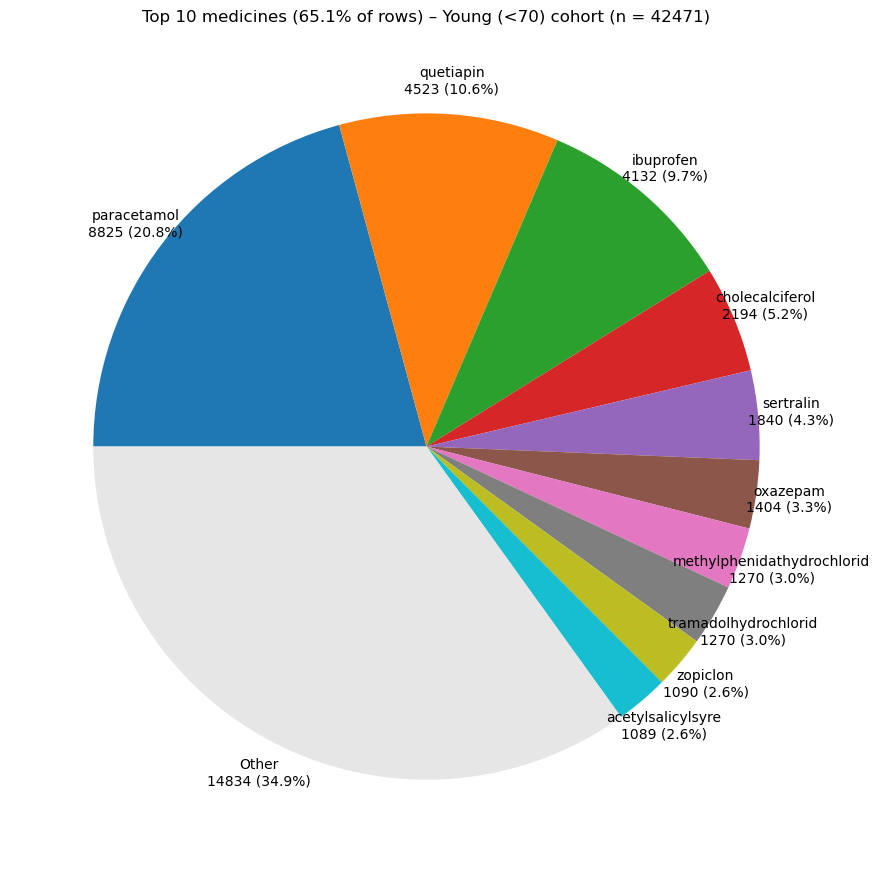

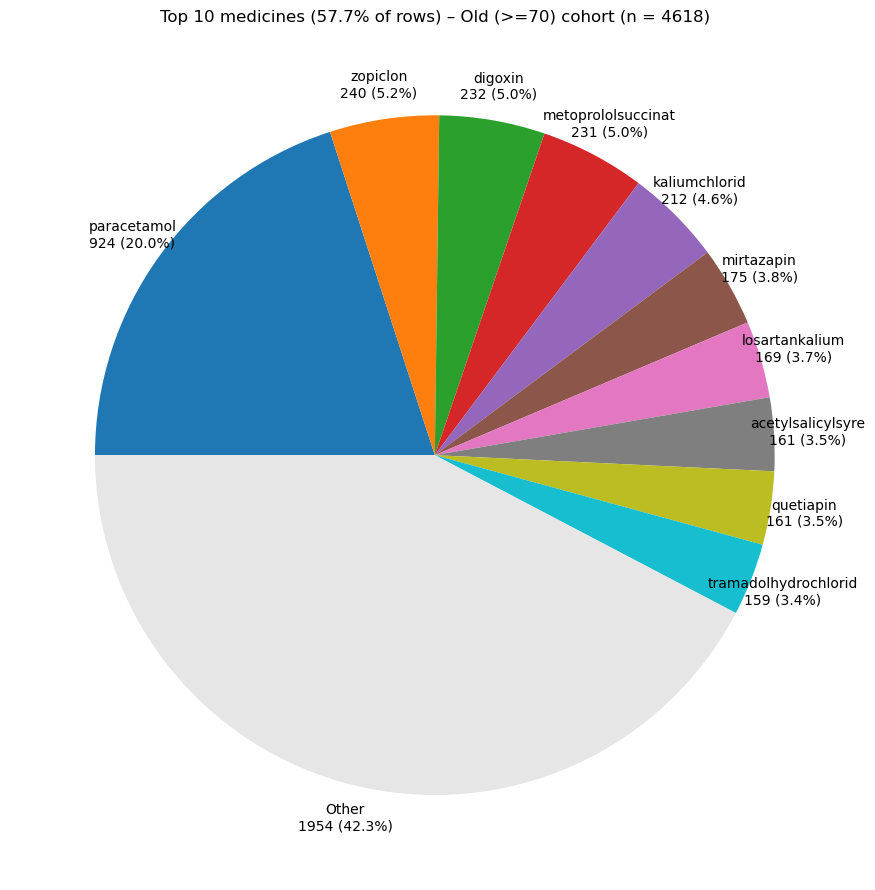

In [62]:
def build_pie_chart_data(df: pd.DataFrame, total_rows: int, top_n: int = 10):
    """Counts unique medicine occurrences per row and prepares data for matplotlib."""
    counter = Counter()
    for _, row in df[NAME_COLS].iterrows():
        present = set()
        for col in NAME_COLS:
            val = row[col]
            if pd.isnull(val): continue
            
            for tok in split_words(str(val)):
                if tok in medicines:
                    canonical_tok = synonym_to_canonical.get(tok, tok)
                    present.add(canonical_tok)
        counter.update(present)
        
    top = counter.most_common(top_n)
    labels = [drug for drug, _ in top]
    counts = [cnt for _, cnt in top]

    other_cnt = total_rows - sum(counts)
    if other_cnt > 0:
        labels.append("Other")
        counts.append(other_cnt)

    percents = [c / total_rows * 100 for c in counts]
    coverage_pct = sum(counts[:-1]) / total_rows * 100 if other_cnt > 0 else 100.0
    
    return labels, counts, percents, coverage_pct

def render_pie_chart(labels, counts, percents, coverage_pct, cohort_name, total_rows):
    """Draws a clean pie chart with percentages and a light grey 'Other' slice."""
    full_labels = [f"{lab}\n{cnt} ({pct:.1f}%)" for lab, cnt, pct in zip(labels, counts, percents)]

    base_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
    colors = ["#E6E6E6" if lab.lower() == "other" else next(base_cycle) for lab in labels]

    plt.figure(figsize=(9, 9))
    plt.pie(
        counts,
        labels=full_labels,
        colors=colors,
        startangle=180, 
        counterclock=False,
        textprops={"ha": "center"},
    )

    plt.title(f"Top 10 medicines ({coverage_pct:.1f}% of rows) – {cohort_name} cohort (n = {total_rows})")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------------
# Execution
# ---------------------------------------------------------------------------
# Render chart for Young cohort
y_labels, y_counts, y_pcts, y_cov = build_pie_chart_data(young, len(young))
render_pie_chart(y_labels, y_counts, y_pcts, y_cov, "Young (<70)", len(young))

# Render chart for Old cohort
o_labels, o_counts, o_pcts, o_cov = build_pie_chart_data(old, len(old))
render_pie_chart(o_labels, o_counts, o_pcts, o_cov, "Old (>=70)", len(old))